# 0_12 — Serum half-life data for validation B

## Scope

Validation B of the specification asks whether peptides predicted to be more
proteolysis-prone degrade faster in human serum. The label is the observed
degradation rate

$$k_{obs} = \frac{\ln 2}{t_{1/2}}.$$

Two sources were acquired: PEPlife2, queried for human serum and human plasma,
and the DRAMP stability set. This notebook counts the observations that survive
the filters of the acquisition contract. The count determines which statistical
question can be asked: a rank correlation or a calibrated fit.

## Filters

Human serum, in vitro, linear, quantitative half-life with a unit, explicit
sequence, standard residues only. Plasma is retained as a separate matrix and
is not merged into the serum set. Chemically modified peptides are retained and
flagged rather than reduced to their unmodified sequence.

## Execution contract

**Inputs:** `data/serum_proteolysis_calibration/raw/peplife2/human_serum.json`; `data/serum_proteolysis_calibration/raw/peplife2/human_plasma.json`; `data/serum_proteolysis_calibration/raw/dramp/stability_amps.xlsx`.

**Outputs:** `results/0_12_serum_halflife_coverage.csv`.

**Depends on:** none.

**Boundary:** Half-life coverage alone does not calibrate the MEROPS score or prove causal proteolysis.

In [1]:
import json
import re
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import MEROPS_AMINO_ACIDS

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
PEPLIFE_SERUM = common.SERUM_RAW / "peplife2" / "human_serum.json"
PEPLIFE_PLASMA = common.SERUM_RAW / "peplife2" / "human_plasma.json"
DRAMP_STABILITY = common.SERUM_RAW / "dramp" / "stability_amps.xlsx"

# Conversion of the reported half-life unit to minutes.
UNIT_TO_MINUTES = {
    "minute": 1.0, "minutes": 1.0, "min": 1.0,
    "hour": 60.0, "hours": 60.0, "h": 60.0, "hr": 60.0,
    "day": 1440.0, "days": 1440.0,
    "second": 1 / 60, "seconds": 1 / 60, "sec": 1 / 60,
}
NUMERIC = re.compile(r"^\s*([0-9]*\.?[0-9]+)\s*$")
STANDARD_SEQUENCE = re.compile(f"^[{MEROPS_AMINO_ACIDS}]+$")

In [3]:
for path in (PEPLIFE_SERUM, PEPLIFE_PLASMA, DRAMP_STABILITY):
    record = common.describe_source(path)
    print(f"{record['path']} | exists={record['exists']} | {record['bytes'] / 1e3:.0f} kB")

data/serum_proteolysis_calibration/raw/peplife2/human_serum.json | exists=True | 183 kB
data/serum_proteolysis_calibration/raw/peplife2/human_plasma.json | exists=True | 422 kB
data/serum_proteolysis_calibration/raw/dramp/stability_amps.xlsx | exists=True | 24 kB


In [4]:
def load_peplife(path: Path, matrix: str) -> pd.DataFrame:
    """Load one PEPlife2 media query into a table.

    :param path: Raw JSON response stored by the downloader.
    :param matrix: Biological matrix label for the records.
    :return: Records with the source fields preserved.
    """

    payload = json.loads(path.read_text())
    frame = pd.DataFrame(payload["data"])
    frame["matrix"] = matrix
    frame["source"] = "peplife2"
    return frame


def to_minutes(value: str, unit: str) -> float:
    """Convert one reported half-life to minutes.

    :param value: Reported half-life; non-numeric entries yield ``nan``.
    :param unit: Reported unit.
    :return: Half-life in minutes, or ``nan`` when it cannot be converted.
    """

    match = NUMERIC.match(str(value))
    factor = UNIT_TO_MINUTES.get(str(unit).strip().lower())
    if match is None or factor is None:
        return float("nan")
    return float(match.group(1)) * factor


serum = load_peplife(PEPLIFE_SERUM, "human_serum")
plasma = load_peplife(PEPLIFE_PLASMA, "human_plasma")
peplife = pd.concat([serum, plasma], ignore_index=True)

peplife["half_life_min"] = [
    to_minutes(value, unit) for value, unit in zip(peplife["half_life"], peplife["units_half"])
]
peplife["is_in_vitro"] = peplife["vivo_vitro"].str.strip().str.lower().eq("in vitro")
peplife["is_linear"] = peplife["lin_cyc"].str.strip().str.lower().str.startswith("linear")
peplife["is_standard_sequence"] = peplife["seq"].str.upper().str.fullmatch(STANDARD_SEQUENCE)
peplife["is_modified"] = ~peplife["chem_mod"].str.strip().str.lower().isin(["none", "", "nan"])

print(f"PEPlife2 records: serum {len(serum)}, plasma {len(plasma)}")
print()
print(peplife.groupby("matrix")[["is_in_vitro", "is_linear", "is_standard_sequence"]].mean().round(3).to_string())

PEPlife2 records: serum 170, plasma 378

              is_in_vitro  is_linear  is_standard_sequence
matrix                                                    
human_plasma        0.410      0.817                 0.704
human_serum         0.694      0.682                 0.900


## Effect of each filter

Each filter is a requirement of the acquisition contract. The counts below show
at which filter the usable set is reduced.

The serum funnel counts records after each stated criterion; the admissible set requires a quantitative half-life with a unit and a standard sequence. The later plot tests whether usable half-lives span more than one peptide length and time scale. If nearly all remaining labels have one length or one half-life range, a rank test would be confounded or uninformative.


In [5]:
serum_records = peplife.query("matrix == 'human_serum'")
funnel = {
    "records returned": len(serum_records),
    "quantitative half-life": int(serum_records["half_life_min"].notna().sum()),
    "+ in vitro": int((serum_records["half_life_min"].notna() & serum_records["is_in_vitro"]).sum()),
    "+ linear": int(
        (
            serum_records["half_life_min"].notna()
            & serum_records["is_in_vitro"]
            & serum_records["is_linear"]
        ).sum()
    ),
    "+ standard residues": int(
        (
            serum_records["half_life_min"].notna()
            & serum_records["is_in_vitro"]
            & serum_records["is_linear"]
            & serum_records["is_standard_sequence"]
        ).sum()
    ),
}
for label, value in funnel.items():
    print(f"{label:24s} {value:5d}")

usable = serum_records[
    serum_records["half_life_min"].notna()
    & serum_records["is_in_vitro"]
    & serum_records["is_linear"]
    & serum_records["is_standard_sequence"]
].copy()
usable["sequence"] = usable["seq"].str.upper()
usable["k_obs_per_min"] = np.log(2) / usable["half_life_min"]
usable["length"] = usable["sequence"].str.len()

print()
print(f"usable observations: {len(usable)} | distinct sequences: {usable['sequence'].nunique()}")
print(f"distinct publications: {usable['pmid'].nunique()}")
print(f"chemically modified among them: {int(usable['is_modified'].sum())}")
print(f"half-life range: {usable['half_life_min'].min():.1f}–{usable['half_life_min'].max():.1f} min")
print(f"length range: {usable['length'].min()}–{usable['length'].max()} residues")

records returned           170
quantitative half-life      81
+ in vitro                  59
+ linear                    37
+ standard residues         32

usable observations: 32 | distinct sequences: 19
distinct publications: 16
chemically modified among them: 6
half-life range: 2.0–7020.0 min
length range: 2–70 residues


## DRAMP as a secondary source

DRAMP is deduplicated against PEPlife2 on sequence. Its half-life column is
free text, so a numeric value is extracted only where a value and a unit are
both present, and entries are retained only where the record refers to serum.

In the figure, the left x-axis lists successive PEPlife2 serum filters and the y-axis counts records. The right panel plots each usable peptide by sequence length (residues) and reported half-life converted to minutes (log y-axis); the labelled extreme points are the longest-lived sequences. These are heterogeneous literature observations, not a controlled length experiment.


In [6]:
dramp = pd.read_excel(DRAMP_STABILITY)
dramp["sequence"] = dramp["Sequence"].astype(str).str.upper().str.strip()
dramp["is_standard_sequence"] = dramp["sequence"].str.fullmatch(STANDARD_SEQUENCE)
dramp["mentions_serum"] = (
    dramp["Assay"].astype(str).str.lower().str.contains("serum")
    | dramp["Type"].astype(str).str.lower().str.contains("serum")
    | dramp["half_life"].astype(str).str.lower().str.contains("serum")
)
dramp["is_linear"] = dramp["Linear/Cyclic/Branched"].astype(str).str.lower().str.startswith("linear")

## The half-life column is free text, so a numeric value is extracted only where
## a value and a unit are unambiguously present.
extracted = dramp["half_life"].astype(str).str.extract(
    r"(?P<value>[0-9]*\.?[0-9]+)\s*(?P<unit>minutes?|min|hours?|h|days?|seconds?|sec)\b",
    flags=re.IGNORECASE,
)
dramp["half_life_min"] = [
    to_minutes(value, unit) for value, unit in zip(extracted["value"], extracted["unit"])
]

print(f"DRAMP stability records: {len(dramp)}")
print(f"  standard residues:        {int(dramp['is_standard_sequence'].sum())}")
print(f"  mentioning serum:         {int(dramp['mentions_serum'].sum())}")
print(f"  numeric half-life parsed: {int(dramp['half_life_min'].notna().sum())}")

dramp_usable = dramp[
    dramp["is_standard_sequence"] & dramp["mentions_serum"] & dramp["half_life_min"].notna()
]
new_sequences = set(dramp_usable["sequence"]) - set(usable["sequence"])
print(f"  usable after all filters: {len(dramp_usable)}")
print(f"  adding sequences not already in PEPlife2: {len(new_sequences)}")

DRAMP stability records: 110
  standard residues:        87
  mentioning serum:         89
  numeric half-life parsed: 101
  usable after all filters: 64
  adding sequences not already in PEPlife2: 49


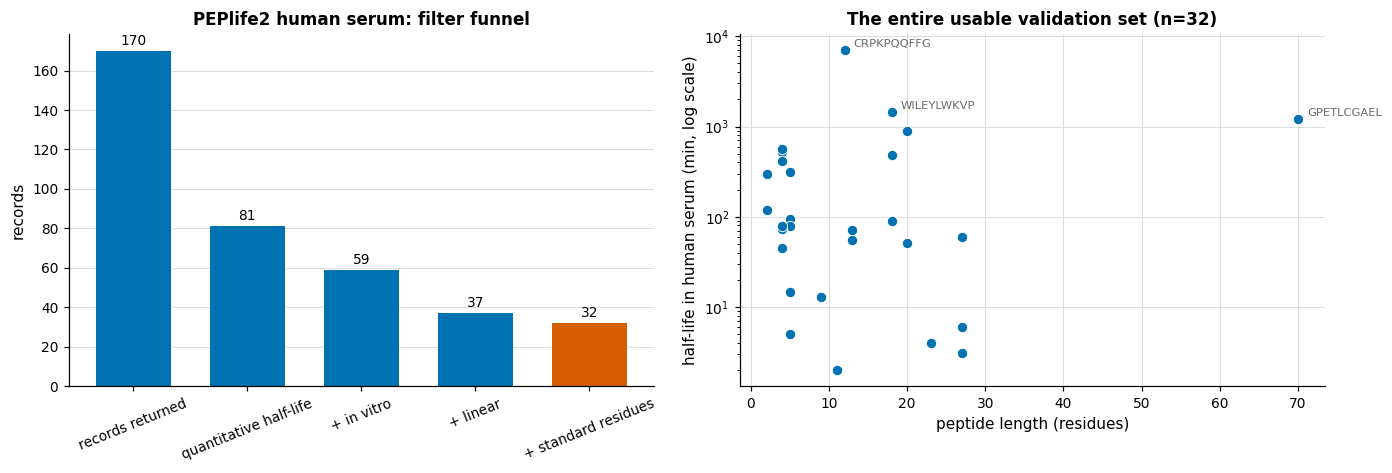

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.4))

ax = axes[0]
labels = list(funnel.keys())
values = list(funnel.values())
bars = ax.bar(
    labels,
    values,
    color=[common.CATEGORICAL_COLORS[0]] * (len(values) - 1) + [common.CATEGORICAL_COLORS[1]],
    width=0.66,
)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 3, str(value), ha="center", fontsize=9)
ax.set_ylabel("records")
ax.set_title("PEPlife2 human serum: filter funnel")
ax.tick_params(axis="x", rotation=22)
ax.grid(axis="x", visible=False)

ax = axes[1]
ax.scatter(
    usable["length"],
    usable["half_life_min"],
    s=46,
    color=common.CATEGORICAL_COLORS[0],
    edgecolor="white",
    linewidth=0.6,
)
ax.set_yscale("log")
ax.set_xlabel("peptide length (residues)")
ax.set_ylabel("half-life in human serum (min, log scale)")
ax.set_title(f"The entire usable validation set (n={len(usable)})")
for _, row in usable.nlargest(3, "half_life_min").iterrows():
    ax.annotate(
        row["sequence"][:10],
        (row["length"], row["half_life_min"]),
        textcoords="offset points",
        xytext=(6, 2),
        fontsize=7.5,
        color=common.NEUTRAL,
    )
fig.tight_layout()
plt.show()

**Provenance**

PEPlife2 human-serum and human-plasma responses are stored in `data/serum_proteolysis_calibration/raw/peplife2/human_serum.json` and `human_plasma.json`, acquired by `assets/scripts/downloads/serum_proteolysis_calibration/download_peplife2.py`. DRAMP stability records are in `raw/dramp/stability_amps.xlsx`, acquired by `download_fixed_sources.py` (DRAMP 3.0) through `download_serum_sources.py`; see the raw download manifests. One observation is a reported peptide half-life, not one unique sequence or publication. Code cells 5–9 parse units, keep quantitative in-vitro human serum measurements with standard sequence, and keep plasma and DRAMP separate. `results/0_12_serum_halflife_coverage.csv` records 32 serum observations / 19 sequences / 16 publications, 378 plasma observations / 145 sequences / 104 publications, and 64 DRAMP observations / 49 sequences / 11 publications. The conversion `k_obs = ln(2)/t_half` assumes first-order decay and consistent time units. Check the raw JSON fields and DRAMP workbook rows via code cells 5–9; source release identifiers and filter-by-filter counts are not saved: TODO: provenance do ustalenia. These literature half-lives mix assays and cannot by themselves identify the responsible serum proteases.


## Statistical question the set supports

The observations come from unrelated protocols, and the reproducibility of
repeated sequences bounds what can be fitted. The test is stated here, before
any model is fitted, so that it is not selected after the outcome is known.

In [8]:
per_publication = usable.groupby("pmid").agg(
    n_observations=("sequence", "size"), n_sequences=("sequence", "nunique")
)
print(f"observations per publication: median {per_publication['n_observations'].median():.0f}, "
      f"max {per_publication['n_observations'].max()}")
print(f"publications contributing a single sequence: "
      f"{int((per_publication['n_sequences'] == 1).sum())} / {len(per_publication)}")
print()
print("half-life spread within repeated sequences:")
repeated = usable.groupby("sequence")["half_life_min"].agg(["size", "min", "max"]).query("size > 1")
print(repeated.to_string() if len(repeated) else "  no sequence measured more than once")

print()
print("planned test for validation B: Spearman rank correlation between the "
      "predicted susceptibility and k_obs, reported with a confidence interval; "
      "no absolute calibration of k_obs from this set.")

observations per publication: median 2, max 5
publications contributing a single sequence: 13 / 16

half-life spread within repeated sequences:
                             size    min     max
sequence                                        
KIKIPWGKVKDFLVGGMKAV            4  900.0   900.0
RLYE                            5   73.0   564.0
SDKP                            2   45.0   420.0
VIKLSGRELVRAQIAISGMSTWSKRSL     2    6.0    60.0
WILEYLWKVPFDFWRGVI              2  480.0  1440.0
YGGFL                           4   14.7   315.0

planned test for validation B: Spearman rank correlation between the predicted susceptibility and k_obs, reported with a confidence interval; no absolute calibration of k_obs from this set.


In [9]:
coverage = pd.DataFrame(
    [
        {
            "source": "peplife2_human_serum",
            "matrix": "human_serum",
            "measurement_type": "half_life_in_vitro",
            "derived_label": "k_obs = ln2 / t_half",
            "absolute_scale": True,
            "n_observations": len(usable),
            "n_unique_sequences": int(usable["sequence"].nunique()),
            "n_publications": int(usable["pmid"].nunique()),
            "validation_level": "B",
            "verdict": "rank_test_only",
        },
        {
            "source": "peplife2_human_plasma",
            "matrix": "human_plasma",
            "measurement_type": "half_life",
            "derived_label": "k_obs = ln2 / t_half",
            "absolute_scale": True,
            "n_observations": int(len(plasma)),
            "n_unique_sequences": int(plasma["seq"].nunique()),
            "n_publications": int(plasma["pmid"].nunique()),
            "validation_level": "B_secondary_matrix",
            "verdict": "kept_separate_from_serum",
        },
        {
            "source": "dramp_stability",
            "matrix": "serum_mentioned",
            "measurement_type": "half_life_free_text",
            "derived_label": "k_obs = ln2 / t_half",
            "absolute_scale": True,
            "n_observations": int(len(dramp_usable)),
            "n_unique_sequences": int(len(new_sequences)),
            "n_publications": int(dramp_usable["Pubmed_ID"].nunique()),
            "validation_level": "B_secondary_source",
            "verdict": "rank_test_only",
        },
    ]
)
destination = common.save_result(coverage, "0_12_serum_halflife_coverage.csv")
print(f"written: {destination.relative_to(common.ROOT)}")
coverage

written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_12_serum_halflife_coverage.csv


,source,matrix,measurement_type,derived_label,absolute_scale,n_observations,n_unique_sequences,n_publications,validation_level,verdict
0,peplife2_human_serum,human_serum,half_life_in_vitro,k_obs = ln2 / t_half,True,32,19,16,B,rank_test_only
1,peplife2_human_plasma,human_plasma,half_life,k_obs = ln2 / t_half,True,378,145,104,B_secondary_matrix,kept_separate_from_serum
2,dramp_stability,serum_mentioned,half_life_free_text,k_obs = ln2 / t_half,True,64,49,11,B_secondary_source,rank_test_only
